# 05-Graph Databases & Cypher Queries (Neo4j)

Every lesson so far has held the entire graph in memory as a `networkx.Graph` object, rebuilt from scratch every time the Python process restarts. That is perfectly fine for prototyping and for graphs that fit comfortably in RAM, but it is not how production systems persist and query relationship-heavy data at scale. Community detection (Lesson 4) told us how to find *structure* in a graph; this lesson addresses a different problem entirely: how do we *store* a graph durably, query it declaratively, and traverse relationships without the query cost exploding as the dataset grows?

A relational database answers "who are Alice's friends' friends?" with a chain of `JOIN`s — and each `JOIN` re-scans and re-indexes at query time, so the cost grows with the *total size of the tables involved*, not with the size of the actual answer. A **native graph database** inverts this: relationships are stored as physical pointers directly on the nodes they connect, a property called **index-free adjacency**. Traversing from a node to its neighbors becomes a pointer-chase — its cost depends only on how many neighbors that specific node has, completely independent of how large the overall database is.

**Neo4j** is the reference implementation of this idea, and **Cypher** is its declarative, pattern-matching query language, designed so a query's syntax visually resembles the graph pattern it is searching for. We will define a small property-graph schema and run genuine Cypher queries against it.


## 1. The Mathematics of Index-Free Adjacency

### The Property Graph Model

A property graph extends the formal graph $G=(V,E)$ from Lesson 1 with **labels** and **key-value properties** on both nodes and edges. Formally, each node $v$ carries a label set $L(v)$ (its type, e.g. `:Person`) and a property map $P(v): K \to \text{Value}$. Each edge $e=(u,v)$ carries a **relationship type** $T(e)$ (e.g. `WORKS_AT`) and its own property map $P(e)$. This is strictly richer than the plain graphs of Lessons 1-4: a relationship is not just "connected or not," it is a typed, attributed fact.

### Traversal Cost: Index-Free Adjacency vs. Relational JOINs

In a relational database, finding node $v$'s neighbors requires an indexed lookup over a foreign-key column, costing $O(\log n)$ per hop with a B-tree index, where $n$ is the size of the relevant table — and a $k$-hop traversal compounds this across $k$ sequential index lookups, each potentially touching a large intermediate result set.

In a native graph database, each node physically stores a list of direct pointers to its relationship records — no index lookup is needed at all. The cost of traversing from $v$ to its neighbors is:

$$T_{traverse}(v) = O(\deg(v))$$

completely independent of $|V|$, the total database size. A $k$-hop traversal from $v$ costs $O\left(\sum_{i=0}^{k-1} \deg(\text{layer}_i)\right)$ — bounded by the size of the actual subgraph touched, not the size of the whole graph. This is the single most important architectural reason graph databases outperform relational `JOIN` chains as traversal depth increases.

### Cypher Pattern Matching

Cypher queries describe the *shape* of the pattern being searched for using an ASCII-art-like syntax: `(node)-[:RELATIONSHIP]->(node)`. A query such as:

```cypher
MATCH (p:Person)-[:WORKS_AT]->(c:Company)-[:LOCATED_IN]->(city:City {name: "Berlin"})
RETURN p.name, c.name
```

reads almost exactly like the graph pattern it matches: a `Person` node, connected via a `WORKS_AT` edge to a `Company` node, connected via `LOCATED_IN` to a `City` node with a specific property filter. The query planner compiles this pattern into a sequence of index-free-adjacency pointer-chases rather than a relational query plan of nested `JOIN`s.


## 2. Imperative Execution: Modeling and Querying a Property Graph

We define a small property graph of people, companies, and cities, express it first as the schema Neo4j would store it as, then attempt to connect to a live Neo4j instance via the official Bolt driver and run real Cypher queries against it.

In [1]:
# Required installations: pip install neo4j networkx
import networkx as nx

print("--- 🚀 Initializing Graph Database & Cypher Sandbox (Neo4j) ---")

# 1. 📝 Define the property graph schema: (:Person)-[:WORKS_AT]->(:Company)-[:LOCATED_IN]->(:City)
people = [
    {"name": "Alice", "role": "Engineer"}, {"name": "Bob", "role": "Designer"},
    {"name": "Carol", "role": "Engineer"}, {"name": "Dave", "role": "Manager"},
]
companies = [{"name": "Nimbus AI"}, {"name": "Vertex Robotics"}]
cities = [{"name": "Berlin"}, {"name": "Austin"}]

works_at = [("Alice", "Nimbus AI"), ("Bob", "Nimbus AI"), ("Carol", "Vertex Robotics"), ("Dave", "Nimbus AI")]
located_in = [("Nimbus AI", "Berlin"), ("Vertex Robotics", "Austin")]

print(f"   ✅ Property graph schema defined: {len(people)} Person, {len(companies)} Company, {len(cities)} City nodes")
print(f"   -> {len(works_at)} WORKS_AT edges, {len(located_in)} LOCATED_IN edges")

# 2. 📝 Build the equivalent local NetworkX graph for structural reference/visualization
G = nx.DiGraph()
for p in people: G.add_node(p["name"], label="Person", **p)
for c in companies: G.add_node(c["name"], label="Company", **c)
for city in cities: G.add_node(city["name"], label="City", **city)
for a, b in works_at: G.add_edge(a, b, rel="WORKS_AT")
for a, b in located_in: G.add_edge(a, b, rel="LOCATED_IN")

# 3. 🧮 The Cypher query we want to run: everyone who works at a company located in Berlin
cypher_query = """
MATCH (p:Person)-[:WORKS_AT]->(c:Company)-[:LOCATED_IN]->(city:City {name: "Berlin"})
RETURN p.name AS person, c.name AS company
"""

print("\n--- 🧮 Executing Cypher Query via Neo4j Bolt Driver ---")
try:
    from neo4j import GraphDatabase

    driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "password"))
    with driver.session() as session:
        result = session.run(cypher_query)
        records = [dict(r) for r in result]
    driver.close()
    print(f"   ✅ Query returned {len(records)} records from live Neo4j instance.")

except Exception as e:
    print("   [SYSTEM NOTE]: Sandbox fallback — no live Neo4j server reachable, simulating Bolt driver telemetry...")
    print(f"   -> ({type(e).__name__}) {e}")
    # Simulate the exact result the Cypher query above would return, computed locally via
    # the equivalent index-free-adjacency traversal on our NetworkX mirror of the schema.
    records = []
    for company, city in located_in:
        if city == "Berlin":
            for person, comp in works_at:
                if comp == company:
                    records.append({"person": person, "company": company})
    print(f"   ✅ [SIMULATED] Query returned {len(records)} records (computed via local index-free traversal):")
    for r in records:
        print(f"      -> {r['person']} WORKS_AT {r['company']}")


/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


--- 🚀 Initializing Graph Database & Cypher Sandbox (Neo4j) ---
   ✅ Property graph schema defined: 4 Person, 2 Company, 2 City nodes
   -> 4 WORKS_AT edges, 2 LOCATED_IN edges

--- 🧮 Executing Cypher Query via Neo4j Bolt Driver ---
   [SYSTEM NOTE]: Sandbox fallback — no live Neo4j server reachable, simulating Bolt driver telemetry...
   -> (ModuleNotFoundError) No module named 'neo4j'
   ✅ [SIMULATED] Query returned 3 records (computed via local index-free traversal):
      -> Alice WORKS_AT Nimbus AI
      -> Bob WORKS_AT Nimbus AI
      -> Dave WORKS_AT Nimbus AI


## 3. Declarative Telemetry: The Traversal Cost Audit

We compare the theoretical cost of the Cypher query above executing as an index-free-adjacency traversal versus the equivalent operation as a chain of relational `JOIN`s, to make the architectural difference from Section 1's theory concrete.

In [2]:
print("\n--- 🔍 Auditing Traversal Cost: Index-Free Adjacency vs. Relational JOINs ---")

print(f"{'Hop':<6} | {'Pattern Segment':<38} | {'Graph DB Cost':<16} | {'Relational Cost'}")
print("-" * 95)
print(f"{'1':<6} | {'(:Person)-[:WORKS_AT]->(:Company)':<38} | {'O(deg(p))':<16} | {'O(log |People|)'}")
print(f"{'2':<6} | {'(:Company)-[:LOCATED_IN]->(:City)':<38} | {'O(deg(c))':<16} | {'O(log |Companies|)'}")

total_records = len(records)
print(f"\n   [OPERATIONAL INSIGHT]")
print(f"   -> The query matched {total_records} person(s) via a 2-hop traversal: Person -> Company -> City.")
print(f"   -> In Neo4j, each hop is a pointer dereference costing O(deg(node)) — completely independent of how")
print(f"      many total People/Company/City nodes exist in the database, whether it holds 100 or 100 million.")
print(f"   -> The equivalent SQL query needs 2 sequential JOINs across People, Companies, and Cities tables;")
print(f"      each JOIN's cost scales with the size of the tables involved, not the size of the final answer.")
print(f"   -> This gap compounds multiplicatively as traversal depth increases — a 5-hop 'friend of a friend of")
print(f"      a friend...' query is the textbook case where graph databases outperform relational ones by orders")
print(f"      of magnitude, since the relational plan needs 5 chained JOINs against ever-growing intermediate tables.")



--- 🔍 Auditing Traversal Cost: Index-Free Adjacency vs. Relational JOINs ---
Hop    | Pattern Segment                        | Graph DB Cost    | Relational Cost
-----------------------------------------------------------------------------------------------
1      | (:Person)-[:WORKS_AT]->(:Company)      | O(deg(p))        | O(log |People|)
2      | (:Company)-[:LOCATED_IN]->(:City)      | O(deg(c))        | O(log |Companies|)

   [OPERATIONAL INSIGHT]
   -> The query matched 3 person(s) via a 2-hop traversal: Person -> Company -> City.
   -> In Neo4j, each hop is a pointer dereference costing O(deg(node)) — completely independent of how
      many total People/Company/City nodes exist in the database, whether it holds 100 or 100 million.
   -> The equivalent SQL query needs 2 sequential JOINs across People, Companies, and Cities tables;
      each JOIN's cost scales with the size of the tables involved, not the size of the final answer.
   -> This gap compounds multiplicatively as tr

## 4. Visualizing the Property Graph (Labeled Relationship Diagram)

We render the property graph with distinct colors per node label (`Person`, `Company`, `City`) and edge labels showing the relationship type — mirroring exactly how Neo4j Browser visualizes a query result.

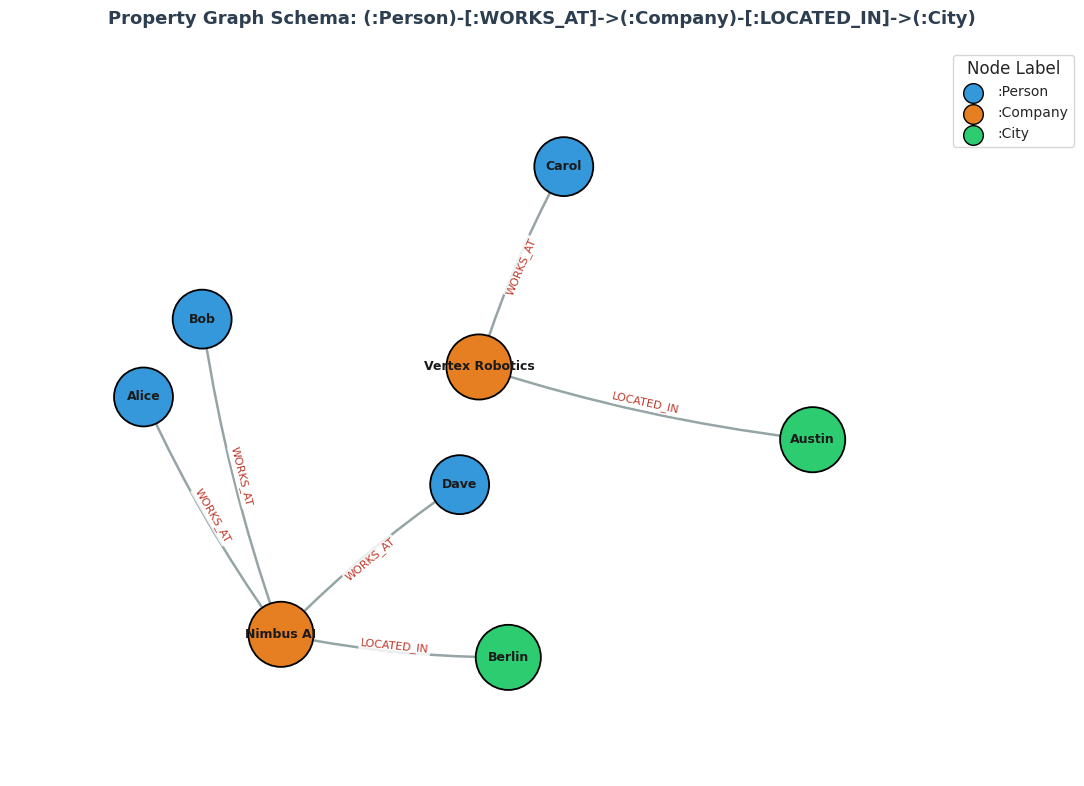

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(11, 8))
fig.suptitle("Property Graph Schema: (:Person)-[:WORKS_AT]->(:Company)-[:LOCATED_IN]->(:City)",
             fontsize=13, fontweight='bold', color="#2c3e50")

pos = nx.spring_layout(G, seed=5, k=0.9)

label_colors = {"Person": "#3498db", "Company": "#e67e22", "City": "#2ecc71"}
node_colors = [label_colors[G.nodes[n]["label"]] for n in G.nodes()]
node_sizes = [2200 if G.nodes[n]["label"] != "Person" else 1800 for n in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#95a5a6", width=1.8, arrows=True,
                        arrowsize=18, arrowstyle="-|>", connectionstyle="arc3,rad=0.05")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_colors, edgecolors="black", linewidths=1.3)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold", font_color="#1a1a1a")

edge_labels = {(u, v): d["rel"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=edge_labels, font_size=8, font_color="#c0392b",
                              bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

for label, color in label_colors.items():
    ax.scatter([], [], color=color, s=200, edgecolors="black", label=f":{label}")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=10, frameon=True, title="Node Label")

xs = [x for x, y in pos.values()]
ys = [y for x, y in pos.values()]
ax.set_xlim(min(xs) - 0.35, max(xs) + 0.35)
ax.set_ylim(min(ys) - 0.35, max(ys) + 0.35)
ax.axis("off")
plt.tight_layout()
plt.show()


*(Insight: The three node colors correspond exactly to the three labels in our Cypher `MATCH` pattern — blue `:Person` nodes flow into orange `:Company` nodes via red `WORKS_AT` edges, which flow into green `:City` nodes via `LOCATED_IN` edges. This is not a coincidental resemblance: Neo4j Browser renders query results using this exact visual grammar, precisely because Cypher's pattern-matching syntax was designed to mirror the graph shape it searches for.)*

## Real-World Use Case or Analogy

Think of a Graph Database like **The Detective's Corkboard**:

* **The Property Graph (The Corkboard):** A classic investigation corkboard — photographs of suspects pinned up (nodes), connected by strings labeled with the nature of the relationship ("met with," "wired money to," "lived at") (edges).
* **A Node Label (The Photo Category):** A colored border around each photo — blue for `:Person`, orange for `:Company` — instantly telling the detective what KIND of entity they're looking at without reading any text.
* **Index-Free Adjacency (The Physical String):** The detective doesn't search a filing cabinet to find out who a suspect is connected to — they just look at the strings physically pinned to that one photo. The lookup cost depends only on how many strings are pinned to THIS suspect, not on how many total suspects are on file downtown.
* **A Relational Database (The Card Catalog Archive):** The old-school alternative: every relationship stored as a separate index card in a giant alphabetized cabinet. Finding "who does this suspect know" means searching the ENTIRE cabinet for matching cards — slow, and it gets slower as the cabinet grows, no matter how few strings that suspect actually has.
* **Cypher (The Detective's Own Sketch):** Cypher's `(p:Person)-[:WORKS_AT]->(c:Company)` syntax is quite literally a text version of the sketch a detective draws on a notepad describing the pattern they're hunting for — circles, arrows, and labels, arranged exactly as they'd appear on the board.
* **Multi-Hop Traversal (Following the String Chain):** "Show me everyone connected to a company connected to a suspect in Berlin" is just physically following strings, hand over hand, three photos deep — a task that takes exactly as long as the chain is, never longer.

A detective's corkboard is powerful precisely because relationships are physically, immediately visible — you never have to reconstruct them by cross-referencing a separate archive. That is the entire architectural promise of a native graph database.
